# Code for Normative Representations in Dorrell et al. 2026

Here we optimise a nonnegative representation under different spatial losses.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import vmap, value_and_grad, grad, jit, random
import optax

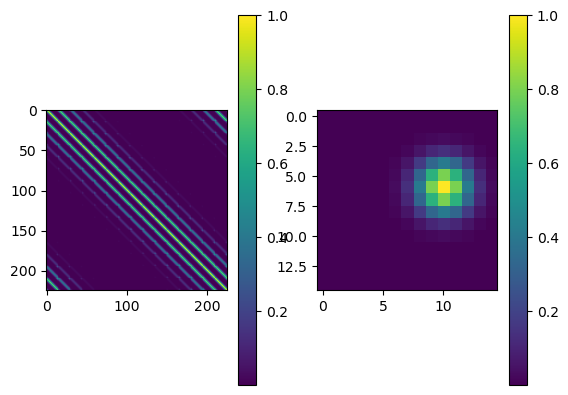

In [30]:
x_lengthscale_sq = 0.02
outer_x_lengthscale_sq = x_lengthscale_sq*3

# Create place cells
x_pos,y_pos = np.meshgrid(np.arange(P)/P, np.arange(P)/P)
pos = np.vstack([np.ndarray.flatten(x_pos), np.ndarray.flatten(y_pos)])
pos_differences = pos[:,None,:] - pos[:,:,None]
pos_differences[pos_differences > 0.5] -= 1
pos_differences[pos_differences < -0.5] += 1
place_cells = np.exp(-jnp.sum((pos_differences)**2,axis=0)/x_lengthscale_sq) - 0*np.exp(-jnp.sum((pos_differences)**2,axis=0)/outer_x_lengthscale_sq)
place_cells = place_cells #- np.mean(place_cells, axis = 1)[:,None]

plt.subplot(1,2,1)
plt.imshow(place_cells)
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(np.reshape(place_cells[100,:], [P,P]))
plt.colorbar()

In [68]:
def setup_pos_loss(loss_choice, params):
    global x_sim
    global x_dist
    
    # Similarity Matching Objectives
    if loss_choice == 0 or loss_choice == 1: 
        # Setup some parameters
        x_lengthscale_sq = 0.035
        alpha = 0.5

        # Let's set up input similarity
        x_pos,y_pos = np.meshgrid(np.arange(params['P'])/params['P'], np.arange(params['P'])/params['P'])
        pos = np.vstack([np.ndarray.flatten(x_pos), np.ndarray.flatten(y_pos)])
        pos_differences = pos[:,None,:] - pos[:,:,None]
        pos_differences[pos_differences > 0.5] -= 1
        pos_differences[pos_differences < -0.5] += 1
        x_sim = np.exp(-jnp.sum((pos_differences)**2,axis=0)/x_lengthscale_sq) - alpha
        
        if loss_choice == 0:
            @jit
            def lin_sim_match(representation):
                neur_sim = representation.T@representation
                return -jnp.sum(jnp.multiply(x_sim,neur_sim))/params['P']**4
            
            return lin_sim_match
            
        elif loss_choice == 1:
            two_sigma_sq = 0.5

            @jit
            def nonlin_sim_match(g):
                neur_sim = jnp.exp(-jnp.sum((g[:,None,:] - g[:,:,None])**2,axis=0)/two_sigma_sq)
                return -jnp.sum(jnp.multiply(x_sim,neur_sim))/P**4

            return nonlin_sim_match

    # Now let's try linear or nonlinear decoding of a place cell representation
    elif loss_choice == 2 or loss_choice == 3:
        x_lengthscale_sq = 0.02

        # Create place cells
        x_pos,y_pos = np.meshgrid(np.arange(params['P'])/params['P'], np.arange(params['P'])/params['P'])
        pos = np.vstack([np.ndarray.flatten(x_pos), np.ndarray.flatten(y_pos)])
        pos_differences = pos[:,None,:] - pos[:,:,None]
        pos_differences[pos_differences > 0.5] -= 1
        pos_differences[pos_differences < -0.5] += 1
        place_cells = np.exp(-jnp.sum((pos_differences)**2,axis=0)/x_lengthscale_sq) 
        place_cells = place_cells# - np.mean(place_cells, axis = 1)[:,None]

        if loss_choice == 2:
            @jit
            def lin_reg(g):
                g_dm = g #- jnp.mean(g, axis = 1)[:,None]
                R = place_cells@jnp.linalg.pinv(g_dm)
                return jnp.linalg.norm(place_cells - R@g_dm)

            return lin_reg

    # Now let's try differnece of gaussian place cells
    elif loss_choice == 4:
        x_lengthscale_sq = 0.02
        outer_x_lengthscale_sq = x_lengthscale_sq*3

        # Create place cells
        x_pos,y_pos = np.meshgrid(np.arange(params['P'])/params['P'], np.arange(params['P'])/params['P'])
        pos = np.vstack([np.ndarray.flatten(x_pos), np.ndarray.flatten(y_pos)])
        pos_differences = pos[:,None,:] - pos[:,:,None]
        pos_differences[pos_differences > 0.5] -= 1
        pos_differences[pos_differences < -0.5] += 1
        place_cells = np.exp(-jnp.sum((pos_differences)**2,axis=0)/x_lengthscale_sq) - 0.75*np.exp(-jnp.sum((pos_differences)**2,axis=0)/outer_x_lengthscale_sq)
        place_cells = place_cells - np.mean(place_cells, axis = 1)[:,None]

        if loss_choice == 4:
            @jit
            def lin_reg(g):
                g_dm = g #- jnp.mean(g, axis = 1)[:,None]
                R = place_cells@jnp.linalg.pinv(g_dm)
                return jnp.linalg.norm(place_cells - R@g_dm)

            return lin_reg

    if loss_choice == 5:
        x_lengthscale_sq = 0.2
        
        # Let's set up input similarity
        x_pos,y_pos = np.meshgrid(np.arange(params['P'])/params['P'], np.arange(params['P'])/params['P'])
        pos = np.vstack([np.ndarray.flatten(x_pos), np.ndarray.flatten(y_pos)])
        pos_differences = pos[:,None,:] - pos[:,:,None]
        pos_differences[pos_differences > 0.5] -= 1
        pos_differences[pos_differences < -0.5] += 1
        x_dist = jnp.sum((pos_differences)**2,axis=0)
        x_sim = jnp.exp(-x_dist/x_lengthscale_sq)

        @jit
        def metric_encoding(g):
            neur_dist = jnp.sum((g[:,None,:] - g[:,:,None])**2,axis=0)
            return jnp.sum(jnp.multiply(x_sim, (x_dist - neur_dist)**2)) - jnp.sum(g)*0.01

        return metric_encoding
    
@jit
def loss_path(g, params, transition_dict):
    Ts = jnp.einsum('tij,jk->tik', jnp.einsum('ij,tjk->tik', params, transition_dict['Ws']), jnp.linalg.pinv(params))
    return jnp.linalg.norm(jnp.einsum('tij,jt->it', Ts, g[:,transition_dict['transitions'][::2]]) - g[:,transition_dict['transitions'][1::2]])


def create_Ws(transitions):
    Ws = np.zeros([num_trans,P**2, P**2])
    for trans in range(num_trans):
        angle_diff = pos[:,transitions[2*trans]] - pos[:,transitions[2*trans+1]]
        angle_diff[angle_diff > 0.5] -= 1
        angle_diff[angle_diff < -0.5] += 1
    
        freq_counter = 0
        for freq_x in range(P):
            for freq_y in range(int(np.floor(P/2))):
                Ws[trans,freq_counter*2,freq_counter*2] = np.cos(2*np.pi*(freq_x*angle_diff[0] + freq_y*angle_diff[1]))
                Ws[trans,freq_counter*2+1,freq_counter*2+1] = np.cos(2*np.pi*(freq_x*angle_diff[0] + freq_y*angle_diff[1]))
                Ws[trans,freq_counter*2,freq_counter*2+1] = np.sin(2*np.pi*(freq_x*angle_diff[0] + freq_y*angle_diff[1]))
                Ws[trans,freq_counter*2+1,freq_counter*2] = -np.sin(2*np.pi*(freq_x*angle_diff[0] + freq_y*angle_diff[1]))
                freq_counter += 1
    Ws[:,-1,-1] = 1
    return Ws

def create_freqs(pos):
    # Setup all the frequencies in case doing path-integrating code
    freqs = np.zeros([P**2, P**2])
    freq_counter = 0
    for freq_x in range(P):
        for freq_y in range(int(np.floor(P/2))):
            freqs[freq_counter,:] = np.cos(2*np.pi*(freq_x*pos[0,:] + freq_y*pos[1,:]))
            freq_counter += 1
            
            freqs[freq_counter,:] = np.sin(2*np.pi*(freq_x*pos[0,:] + freq_y*pos[1,:]))
            freq_counter += 1
    freqs[-1,:] = 1
    freq_counter += 1
    return freqs

In [74]:
# Optimisation parameters
N = 10 # Number of neurons
P = 8 # Number of positions along each axis
loss_choice = 1
mu_path = 10
random_seed = np.random.choice(10000)
learning_rate = 1e-4
learning_rate_anneal_param = 0.9
LR_change_thresh = 5
re_init = 1 # Controls whether you reinitialise the parameters
path_integrating = 0

sep_loss = setup_pos_loss(loss_choice, {'P':P})

if path_integrating:
    @jit
    def loss(params, transition_dict):
        g = gen_g(params)
        return loss_path(g, params, transition_dict)*mu_path + sep_loss(g)
        
    @jit
    def gen_g(params):
        g = params@freqs
        g = params - jnp.min(params)
        g = g/jnp.linalg.norm(g, axis = 1)[:,None]
        return g
else:
    @jit
    def loss(params, transition_dict):
        g = gen_g(params)
        return sep_loss(g)

    @jit
    def gen_g(params):
        g = params - jnp.min(params)
        g = g/jnp.linalg.norm(g, axis = 1)[:,None]
        return g

def measure_goodness(params, transition_dict, verbose = False):
    g = gen_g(params)
    L_s = sep_loss(g)
    
    if path_integrating:
        L_path = loss_path(g, params, transition_dict)
        
        L_t = L_pos*mu_pos + mu_path*L_path + L_s
        if verbose:
            print(f"Total {L_t:.5f}, Path: {L_path:.5f}, Sep: {L_s:.5f}")
        return L_t, L_path, L_s
    else:
        if verbose:
            print(f"Sep: {L_s:.5f}")
        return L_s   

@jit
def update(params, transition_dict, opt_state):
    """ Compute the gradient for a batch and update the parameters """
    value, grads = value_and_grad(loss)(params, transition_dict)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, value

# For path-integrating case
num_trans = 100
replace_trans = 10

# Init stuff
if re_init:
    key = random.PRNGKey(random_seed)
    if path_integrating:
        params = random.normal(key, [N,P**2])*0.1
        params = params.at[:,-1].set(2*F)
    else:
        params = random.normal(key, [N,P**2])*0.0001

if path_integrating:
    transitions = np.random.choice(P**2, [2*num_trans])
    transition_dict = {'Ws':create_Ws(transitions), 'transitions':transitions}
else:
    transition_dict = []

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)
params_best = params
min_loss = np.infty
loss(params, transition_dict)

Array(0.35708284, dtype=float32)

In [79]:
save_iter = 2000 # How often to save the weights
T = 100000 # Number of gradient descent steps
stable_counter = 0
min_this_step = 0

for t in range(T):
    params, opt_state, loss_val = update(params, transition_dict, opt_state)
    
    if t % replace_trans == 0 and path_integrating:
        transitions = np.random.choice(P**2, [2*num_trans])
        transition_dict = {'Ws':create_Ws(transitions), 'transitions':transitions}
        
    if t % save_iter == 0:
        loss_vals = measure_goodness(params, transition_dict, verbose = True)

        if min_this_step == 0:
            stable_counter += 1
                    
        if stable_counter == LR_change_thresh:
            learning_rate *= learning_rate_anneal_param
            optimizer = optax.adam(learning_rate)
            opt_state = optimizer.init(params)
            stable_counter = 0
            print(f'New Learning Rate: {learning_rate}')

        min_this_step = 0

        
    if loss_val < min_loss:
        params_best = params
        min_loss = loss_val

        if min_this_step == 0:
            print(f'New min! {loss_val}')
            min_this_step = 1


Sep: 0.21856
Sep: 0.21856
New min! 0.2185600996017456
Sep: 0.21856
New min! 0.21855999529361725
Sep: 0.21856
New min! 0.2185598462820053
Sep: 0.21856
New min! 0.21855983138084412
Sep: 0.21856
New min! 0.2185596227645874
Sep: 0.21856
Sep: 0.21856
New min! 0.21855944395065308
Sep: 0.21856
New min! 0.21855942904949188
Sep: 0.21856
New min! 0.21855926513671875
Sep: 0.21856
New min! 0.21855907142162323
Sep: 0.21856
Sep: 0.21856
New min! 0.21855878829956055
Sep: 0.21856
New min! 0.21855831146240234
Sep: 0.21856
Sep: 0.21856
New Learning Rate: 7.290000000000001e-05
Sep: 0.21865
Sep: 0.21856
Sep: 0.21856
New min! 0.21855829656124115
Sep: 0.21856
New min! 0.2185579538345337
Sep: 0.21856
New min! 0.2185574322938919
Sep: 0.21856
Sep: 0.21856
Sep: 0.21856
New Learning Rate: 6.561000000000002e-05
Sep: 0.21864
Sep: 0.21856
New min! 0.2185571938753128
Sep: 0.21856
Sep: 0.21856
Sep: 0.21856
Sep: 0.21856
New Learning Rate: 5.904900000000002e-05
Sep: 0.21864
Sep: 0.21856
New min! 0.21855714917182922
Sep

0.21855572


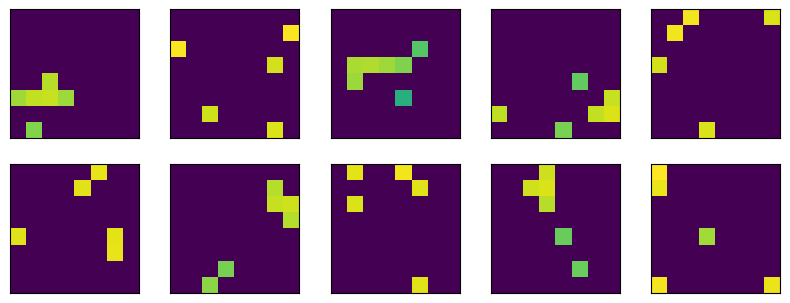

In [80]:
g_best = gen_g(params_best)

fig = plt.figure(figsize = (10, 80))
fig.tight_layout()
for n in range(N):
    plt.subplot(40,5,n+1)
    plt.imshow(np.reshape(g_best[n,:], [P, P]))#, cmap = 'coolwarm')
    #plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.clim([0, np.max(np.abs(g_best))])
    
    
print(min_loss)

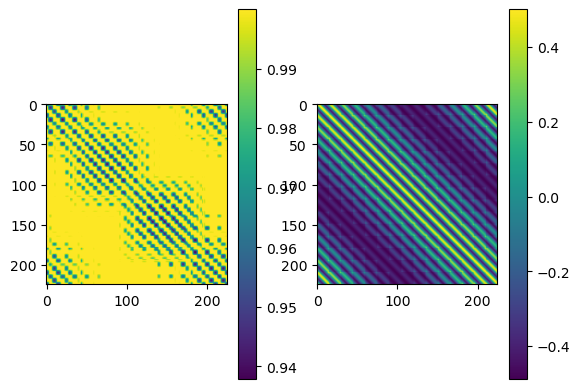

In [17]:
neur_sim = np.exp(-g_best.T@g_best)

plt.subplot(1,2,1)
plt.imshow(neur_sim)
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(x_sim)
plt.colorbar()